# Churn Model

### Imports and settings

In [1]:
import pandas as pd                                                    # tables
import numpy as np                                                     # maths
import matplotlib.pyplot as plt                                        # charts
from pathlib import Path                                               # file paths
from sklearn.compose import ColumnTransformer                          # different preprocessing for different columns
from sklearn.pipeline import Pipeline                                  # chain preprocessing + model into one object
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer   # encoders and scalers
from sklearn.dummy import DummyClassifier                              # "no skill" baseline
from sklearn.linear_model import LogisticRegression                    # simple, interpretable model
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier   # tree-based models
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict, GridSearchCV   # validation tools
from sklearn.metrics import (roc_auc_score, average_precision_score, log_loss, brier_score_loss,
                             confusion_matrix, classification_report, precision_recall_curve,
                             RocCurveDisplay, PrecisionRecallDisplay)   # evaluation metrics and plots
from sklearn.calibration import CalibrationDisplay                     # are predicted probabilities trustworthy?
from sklearn.inspection import permutation_importance                  # which features matter most

pd.set_option("display.max_columns", None)                             # never hide columns
pd.set_option("display.width", 200)                                    # wide printing
RANDOM_STATE = 42                                                      # one seed for reproducible results

### Paths, data, label and country groups

In [2]:
ROOT = Path.cwd()                                                      # folder the notebook runs in
if ROOT.name == "notebooks":                                           # if inside notebooks/...
    ROOT = ROOT.parent                                                 # ...go up to the project root
DATA = ROOT / "data" / "processed"                                     # data folder
FIG = ROOT / "reports" / "figures"                                     # charts folder
players = pd.read_csv(DATA / "player_features.csv", parse_dates=["cohort_date"])   # modeling table
players["churned_7d"] = 1 - players["returned_within_7d"]              # target: 1 = no return within 7 days
top_countries = players["country"].value_counts().index[:10]           # 10 biggest countries
players["country_group"] = np.where(players["country"].isin(top_countries), players["country"], "All other countries")   # group the rest
NUMERIC = ["d0_engagement_events", "d0_engaged_minutes", "d0_levels_started", "d0_levels_completed", "d0_levels_reset",
           "d0_scores_posted", "d0_currency_spends", "d0_ad_rewards", "d0_friend_challenges", "d0_completed_5_levels",
           "d0_extra_steps_used", "d0_distinct_event_types", "d0_sessions", "d0_avg_session_minutes", "join_hour_utc"]   # day-0 features only
CATEGORICAL = ["platform", "country_group"]                            # text features
print(players.shape, "| churn rate:", round(players["churned_7d"].mean(), 4))   # size and balance

(11066, 30) | churn rate: 0.7135


### Out-of-time split: train on earlier cohorts, test on later cohorts

In [3]:
cutoff = players["cohort_date"].quantile(0.75)                         # date that splits cohorts 75% / 25%
train = players[players["cohort_date"] <= cutoff]                      # earlier joiners
test = players[players["cohort_date"] > cutoff]                        # later joiners (the "future")
X_train, y_train = train[NUMERIC + CATEGORICAL], train["churned_7d"]   # training inputs and target
X_test, y_test = test[NUMERIC + CATEGORICAL], test["churned_7d"]       # test inputs and target
print("Cutoff:", cutoff.date())                                        # split date
print("Train:", X_train.shape, "churn", round(y_train.mean(), 4), "| Test:", X_test.shape, "churn", round(y_test.mean(), 4))

Cutoff: 2018-09-04
Train: (8470, 17) churn 0.6999 | Test: (2596, 17) churn 0.7581


### Preprocessing: log-transform and scale numbers, one-hot encode text

In [4]:
preprocess = ColumnTransformer([
    ("num", Pipeline([("log", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),   # log(1 + x) tames skewed counts
                      ("scale", StandardScaler())]), NUMERIC),        # mean 0, standard deviation 1
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEGORICAL),   # one column per category
])

### Define the candidate models

In [5]:
models = {
    "Baseline (always majority)": DummyClassifier(strategy="prior"),                        # predicts the average churn rate for everyone
    "Logistic Regression": LogisticRegression(max_iter=2000, C=1.0),                         # linear, interpretable
    "Random Forest": RandomForestClassifier(n_estimators=300, min_samples_leaf=20, n_jobs=-1, random_state=RANDOM_STATE),   # many averaged trees
    "Gradient Boosting": HistGradientBoostingClassifier(learning_rate=0.05, max_iter=300, random_state=RANDOM_STATE),        # trees built to fix earlier errors
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)   # 5 folds with the same churn share in each

### Cross-validate on train, then evaluate once on the later-cohort test set

In [6]:
rows = []                                                              # results collector
test_probs = {}                                                        # keep test predictions for charts
for name, model in models.items():                                     # one loop, one model per iteration
    pipe = Pipeline([("prep", preprocess), ("model", model)])          # preprocessing + model
    cv_auc = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="roc_auc")   # 5 ROC-AUC scores on train folds
    pipe.fit(X_train, y_train)                                         # fit on all training rows
    p_train = pipe.predict_proba(X_train)[:, 1]                        # churn probability on train
    p_test = pipe.predict_proba(X_test)[:, 1]                          # churn probability on test
    test_probs[name] = p_test                                          # store for plots
    rows.append({"model": name,
                 "cv_auc_mean": cv_auc.mean(), "cv_auc_std": cv_auc.std(),
                 "train_auc": roc_auc_score(y_train, p_train),         # compare with test to spot overfitting
                 "test_auc": roc_auc_score(y_test, p_test),
                 "test_pr_auc": average_precision_score(y_test, p_test),   # precision-recall area
                 "test_log_loss": log_loss(y_test, p_test),            # penalises confident wrong answers
                 "test_brier": brier_score_loss(y_test, p_test)})      # mean squared error of probabilities
results = pd.DataFrame(rows)                                           # to table
print("Baselines: ROC-AUC 0.500 (random) | PR-AUC", round(y_test.mean(), 4), "(the churn rate itself)")   # what a useless model would score
results["overfit_gap"] = results["train_auc"] - results["test_auc"]     # big gap = memorising the training data
print(results.round(4).to_string(index=False))                         # show

Baselines: ROC-AUC 0.500 (random) | PR-AUC 0.7581 (the churn rate itself)
                     model  cv_auc_mean  cv_auc_std  train_auc  test_auc  test_pr_auc  test_log_loss  test_brier  overfit_gap
Baseline (always majority)       0.5000      0.0000     0.5000    0.5000       0.7581         0.5617      0.1868       0.0000
       Logistic Regression       0.6647      0.0105     0.6699    0.6707       0.8493         0.5296      0.1741      -0.0008
             Random Forest       0.6738      0.0085     0.7704    0.6796       0.8539         0.5251      0.1726       0.0908
         Gradient Boosting       0.6493      0.0096     0.9053    0.6464       0.8321         0.5494      0.1819       0.2589


### Tune the gradient boosting model with a small grid search (train data only)

In [7]:
grid = GridSearchCV(
    Pipeline([("prep", preprocess), ("model", HistGradientBoostingClassifier(max_iter=300, random_state=RANDOM_STATE))]),
    param_grid={"model__learning_rate": [0.03, 0.1], "model__max_depth": [3, None], "model__min_samples_leaf": [20, 60]},   # 8 combinations
    scoring="roc_auc", cv=cv, n_jobs=-1)                               # score each combination with 5-fold ROC-AUC
grid.fit(X_train, y_train)                                             # run the search
print("Best params:", grid.best_params_, "| best CV AUC:", round(grid.best_score_, 4))   # winner
best_pipe = grid.best_estimator_                                       # already refit on all training rows
p_best = best_pipe.predict_proba(X_test)[:, 1]                         # test probabilities
test_probs["Tuned Gradient Boosting"] = p_best                         # add to the chart set
print("Tuned model test AUC:", round(roc_auc_score(y_test, p_best), 4), "| PR-AUC:", round(average_precision_score(y_test, p_best), 4))

Best params: {'model__learning_rate': 0.03, 'model__max_depth': 3, 'model__min_samples_leaf': 20} | best CV AUC: 0.6731
Tuned model test AUC: 0.6772 | PR-AUC: 0.8537


### Chart: ROC and precision-recall curves on the test set

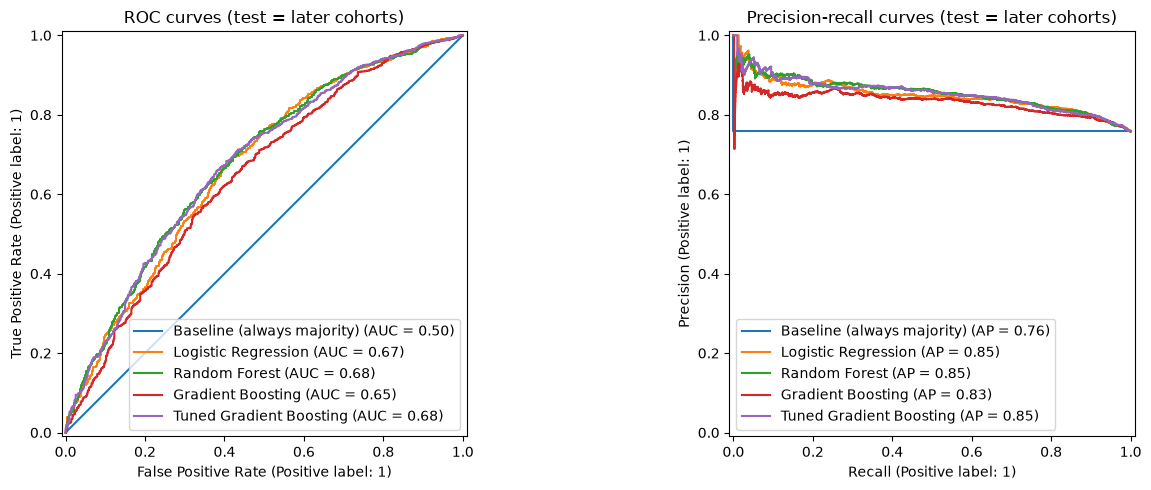

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))                        # two charts
for name, probs in test_probs.items():                                 # one loop, one curve per model
    RocCurveDisplay.from_predictions(y_test, probs, name=name, ax=axes[0])          # ROC curve
    PrecisionRecallDisplay.from_predictions(y_test, probs, name=name, ax=axes[1])   # precision-recall curve
axes[0].set_title("ROC curves (test = later cohorts)")                 # title
axes[1].set_title("Precision-recall curves (test = later cohorts)")    # title
fig.tight_layout()                                                     # tidy
fig.savefig(FIG / "13_roc_pr_curves.png", dpi=150)                     # save
plt.show()                                                             # display

### Choose a decision threshold using training data only, then apply it to test

In [9]:
oof = cross_val_predict(best_pipe, X_train, y_train, cv=cv, method="predict_proba")[:, 1]   # out-of-fold probabilities on train
precision, recall, thresholds = precision_recall_curve(y_train, oof)   # metrics at every threshold
f1 = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-12)   # F1 at each threshold
threshold = thresholds[np.argmax(f1)]                                   # threshold with the best F1 on train
y_pred = (p_best >= threshold).astype(int)                             # apply to test
print("Chosen threshold:", round(threshold, 3))                        # value
print(pd.DataFrame(confusion_matrix(y_test, y_pred), index=["actual returned", "actual churned"], columns=["pred returned", "pred churned"]))   # confusion matrix
print(classification_report(y_test, y_pred, target_names=["returned", "churned"], digits=3))   # precision, recall, F1

Chosen threshold: 0.412
                 pred returned  pred churned
actual returned             93           535
actual churned              86          1882
              precision    recall  f1-score   support

    returned      0.520     0.148     0.230       628
     churned      0.779     0.956     0.858      1968

    accuracy                          0.761      2596
   macro avg      0.649     0.552     0.544      2596
weighted avg      0.716     0.761     0.706      2596



### Calibration: when the model says 70%, do about 70% churn?

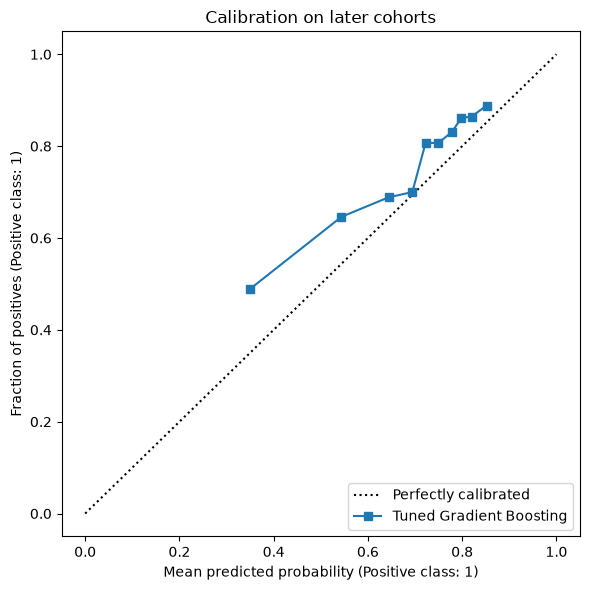

Brier score: 0.1741


In [10]:
fig, ax = plt.subplots(figsize=(6, 6))                                  # square chart
CalibrationDisplay.from_predictions(y_test, p_best, n_bins=10, strategy="quantile", name="Tuned Gradient Boosting", ax=ax)   # reliability curve
ax.set_title("Calibration on later cohorts")                           # title
fig.tight_layout()                                                     # tidy
fig.savefig(FIG / "14_calibration.png", dpi=150)                       # save
plt.show()                                                             # display
print("Brier score:", round(brier_score_loss(y_test, p_best), 4))      # lower is better

### Lift table: how much churn does targeting the riskiest players capture?

In [11]:
lift = pd.DataFrame({"churned": y_test.to_numpy(), "prob": p_best})     # truth and score
lift["decile"] = pd.qcut(lift["prob"].rank(method="first", ascending=False), 10, labels=range(1, 11))   # 1 = riskiest 10%
table = lift.groupby("decile", observed=True).agg(players=("churned", "size"), churners=("churned", "sum"), avg_prob=("prob", "mean"))   # per decile
table["churn_rate"] = table["churners"] / table["players"]             # actual churn rate
table["lift"] = table["churn_rate"] / lift["churned"].mean()           # vs random targeting
table["cumulative_share_of_churners"] = table["churners"].cumsum() / table["churners"].sum()   # captured so far
print(table.round(3))                                                  # show

        players  churners  avg_prob  churn_rate   lift  cumulative_share_of_churners
decile                                                                              
1           260       231     0.852       0.888  1.172                         0.117
2           260       224     0.820       0.862  1.136                         0.231
3           259       223     0.798       0.861  1.136                         0.345
4           260       217     0.778       0.835  1.101                         0.455
5           259       209     0.750       0.807  1.064                         0.561
6           260       210     0.722       0.808  1.065                         0.668
7           259       181     0.694       0.699  0.922                         0.760
8           260       179     0.643       0.688  0.908                         0.851
9           259       167     0.544       0.645  0.851                         0.935
10          260       127     0.349       0.488  0.644           

### Permutation importance: which inputs does the tuned model rely on?

                feature  auc_drop_mean  auc_drop_std
            d0_sessions         0.0452        0.0052
 d0_avg_session_minutes         0.0378        0.0072
    d0_levels_completed         0.0320        0.0046
     d0_engaged_minutes         0.0110        0.0046
   d0_engagement_events         0.0081        0.0022
          join_hour_utc         0.0074        0.0033
d0_distinct_event_types         0.0056        0.0019
       d0_scores_posted         0.0040        0.0034
        d0_levels_reset         0.0025        0.0012
      d0_levels_started         0.0011        0.0006
    d0_extra_steps_used         0.0001        0.0012
   d0_friend_challenges         0.0000        0.0001
               platform        -0.0001        0.0004
  d0_completed_5_levels        -0.0003        0.0004
          d0_ad_rewards        -0.0006        0.0006
     d0_currency_spends        -0.0010        0.0010
          country_group        -0.0015        0.0021


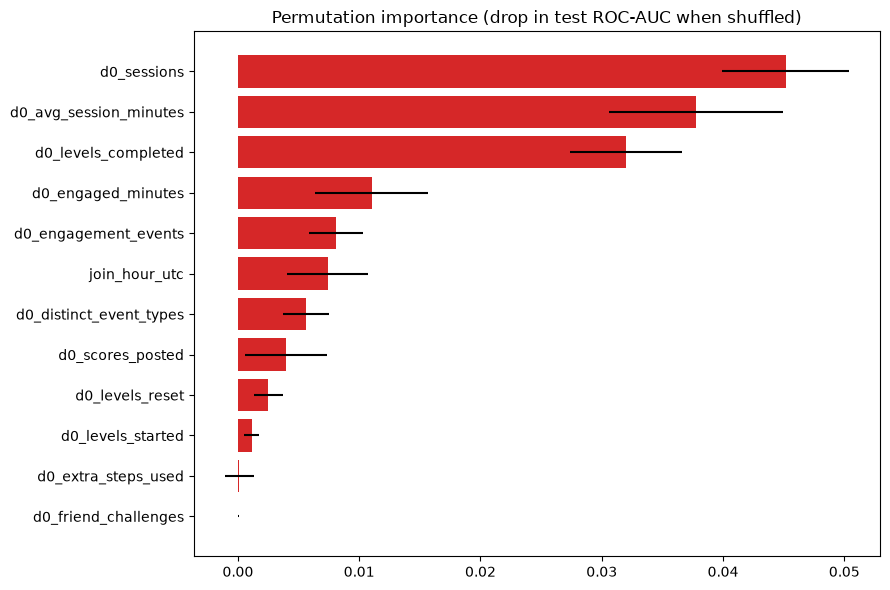

In [12]:
imp = permutation_importance(best_pipe, X_test, y_test, scoring="roc_auc", n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1)   # shuffle one column at a time
importance = pd.DataFrame({"feature": X_test.columns, "auc_drop_mean": imp.importances_mean, "auc_drop_std": imp.importances_std}).sort_values("auc_drop_mean", ascending=False)   # bigger drop = more important
print(importance.round(4).to_string(index=False))                      # table
fig, ax = plt.subplots(figsize=(9, 6))                                 # empty chart
top = importance.head(12).iloc[::-1]                                   # top 12, reversed so the biggest is on top
ax.barh(top["feature"], top["auc_drop_mean"], xerr=top["auc_drop_std"], color="tab:red")   # bars with spread
ax.set_title("Permutation importance (drop in test ROC-AUC when shuffled)")   # title
fig.tight_layout()                                                     # tidy
fig.savefig(FIG / "15_permutation_importance.png", dpi=150)            # save
plt.show()                                                             # display

### Logistic regression odds ratios (direction and size of each effect)

In [13]:
logit_pipe = Pipeline([("prep", preprocess), ("model", LogisticRegression(max_iter=2000))]).fit(X_train, y_train)   # refit logistic model
names = logit_pipe.named_steps["prep"].get_feature_names_out()         # column names after preprocessing
odds = pd.DataFrame({"feature": names, "coefficient": logit_pipe.named_steps["model"].coef_[0]})   # one coefficient per column
odds["odds_ratio_per_1sd"] = np.exp(odds["coefficient"])               # >1 raises churn odds, <1 lowers them
print(odds.sort_values("coefficient").round(3).to_string(index=False)) # most protective features first

                               feature  coefficient  odds_ratio_per_1sd
                      num__d0_sessions       -0.386               0.680
           num__d0_avg_session_minutes       -0.350               0.705
                 num__d0_scores_posted       -0.158               0.853
              cat__country_group_India       -0.154               0.857
                num__d0_levels_started       -0.131               0.877
          cat__country_group_Australia       -0.107               0.899
            num__d0_completed_5_levels       -0.085               0.919
          num__d0_distinct_event_types       -0.072               0.930
               num__d0_currency_spends       -0.041               0.960
              num__d0_levels_completed       -0.032               0.969
                    num__d0_ad_rewards       -0.019               0.982
      cat__country_group_United States       -0.012               0.988
     cat__country_group_United Kingdom       -0.012             

### Business simulation: value of a retention offer for the riskiest players

In [14]:
VALUE_PER_SAVED_PLAYER = 10.0                                          # ASSUMPTION: value of keeping one player (in "value units")
COST_PER_OFFER = 0.5                                                   # ASSUMPTION: cost of sending one offer
scenarios = []                                                         # results collector
ranked = lift.sort_values("prob", ascending=False).reset_index(drop=True)   # riskiest players first
for target_share, save_rate in [(t, s) for t in [0.1, 0.2, 0.3, 0.5] for s in [0.05, 0.10, 0.20]]:   # one flat loop over all combinations
    n_target = int(len(ranked) * target_share)                         # how many players get the offer
    churners_reached = ranked["churned"].iloc[:n_target].sum()         # true churners among them
    net_value = churners_reached * save_rate * VALUE_PER_SAVED_PLAYER - n_target * COST_PER_OFFER   # benefit minus cost
    scenarios.append({"target_share": target_share, "save_rate": save_rate, "offers": n_target,
                      "churners_reached": int(churners_reached), "net_value": round(net_value, 1)})
print(pd.DataFrame(scenarios).pivot(index="target_share", columns="save_rate", values="net_value"))   # net value grid

save_rate     0.05   0.10    0.20
target_share                     
0.1          -14.5  100.5   330.5
0.2          -32.0  195.5   650.5
0.3          -50.0  289.0   967.0
0.5          -97.0  455.0  1559.0


### Save results

In [15]:
results.to_csv(DATA / "model_comparison.csv", index=False)             # model table
importance.to_csv(DATA / "permutation_importance.csv", index=False)    # importance table
pd.DataFrame({"player_id": test["player_id"].to_numpy(), "churned_7d": y_test.to_numpy(), "churn_probability": p_best}).to_csv(DATA / "test_predictions.csv", index=False)   # predictions
print("Saved model outputs")                                           # confirm

Saved model outputs
